##  Cellule 1 — Installation & Authentification

In [ ]:
!pip install earthengine-api torch scikit-learn pandas numpy matplotlib seaborn --quiet

import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings, os, json, shutil
warnings.filterwarnings('ignore')

ee.Authenticate()
ee.Initialize(project='ee-sirinesirinee6')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Tout est prêt ! Device = {DEVICE}')

Tout est prêt ! Device = cpu


## Cellule 3 — Configuration des zones (California + Arkansas)

In [ ]:
YEAR  = 2021
BANDS = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
TARGET_SCALE = 20
TARGET_CRS   = 'EPSG:4326'

DATA_PART2_RAW = '/content/drive/MyDrive/Crop_Classification/data_part2/raw'
os.makedirs(DATA_PART2_RAW, exist_ok=True)
print(f' Dossier Part2 : {DATA_PART2_RAW}')
ZONES = {
    'california': [
        {'name': 'California_Zone1',
         'geometry': ee.Geometry.Rectangle([-122.50, 38.00, -120.50, 40.50])},
        {'name': 'California_Zone2',
         'geometry': ee.Geometry.Rectangle([-121.00, 35.00, -118.50, 38.00])},
    ],
    'arkansas': [
        {'name': 'Arkansas_Zone1',
         'geometry': ee.Geometry.Rectangle([-91.60, 33.50, -89.80, 36.50])},
        {'name': 'Arkansas_Zone2',
         'geometry': ee.Geometry.Rectangle([-95.00, 34.00, -91.60, 36.50])},
    ]
}

CDL_MAP = {
    'california': {
        'from'  : [69,  3,  36,  75, 204],
        'to'    : [ 1,  2,   3,   4,   5],
        'n_cls' : 6,
        'names' : {1:'Grapes',2:'Rice',3:'Alfalfa',4:'Almonds',5:'Pistachios',99:'Others'},
        'colors': ['#8B1A8B','#1E90FF','#FFD700','#FF8C00','#32CD32','#A9A9A9']
    },
    'arkansas': {
        'from'  : [1, 2, 3, 5],
        'to'    : [1, 2, 3, 5],
        'n_cls' : 5,
        'names' : {5:'Soybeans',3:'Rice',1:'Corn',2:'Cotton',99:'Others'},
        'colors': ['#FFD700','#1E90FF','#FF8C00','#FFFFFF','#A9A9A9']
    }
}

CLIMATE_VARS = ['bio01_temp', 'bio12_precip', 'bio15_precip_season']
SOIL_VARS    = ['soil_ph', 'soil_oc', 'soil_clay']
TOPO_VARS    = ['elevation', 'landforms']
ENV_VARS     = CLIMATE_VARS + SOIL_VARS + TOPO_VARS

print('Configuration OK')
print(f'   États       : California + Arkansas')
print(f'   Résolution  : {TARGET_SCALE}m (identique à S2)')
print(f'   Covariables : {ENV_VARS}')

✅ Dossier Part2 : /content/drive/MyDrive/Crop_Classification/data_part2/raw
✅ Configuration OK
   États       : California + Arkansas
   Résolution  : 20m (identique à S2)
   Covariables : ['bio01_temp', 'bio12_precip', 'bio15_precip_season', 'soil_ph', 'soil_oc', 'soil_clay', 'elevation', 'landforms']


##  Cellule 4 — Téléchargement GEE(tout covariables dans une image pour chaque zone)

In [ ]:
def build_env_covariates(geometry):
    def reproject(img, name):
        return (img.rename(name)
                   .reproject(crs=TARGET_CRS, scale=TARGET_SCALE)
                   .clip(geometry))

    wc = ee.Image('WORLDCLIM/V1/BIO')
    bio01 = reproject(wc.select('bio01'), 'bio01_temp')
    bio12 = reproject(wc.select('bio12'), 'bio12_precip')
    bio15 = reproject(wc.select('bio15'), 'bio15_precip_season')

    ph = reproject(
        ee.Image('OpenLandMap/SOL/SOL_PH-H2O_USDA-4C1A2A_M/v02').select('b0'),
        'soil_ph')
    oc = reproject(
        ee.Image('OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02').select('b0'),
        'soil_oc')
    clay = reproject(
        ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02').select('b0'),
        'soil_clay')

    elev = reproject(ee.Image('USGS/SRTMGL1_003').select('elevation'), 'elevation')
    lform = reproject(
        ee.Image('CSP/ERGo/1_0/US/landforms').select('constant'),
        'landforms')

    return (bio01.addBands(bio12).addBands(bio15)
                 .addBands(ph).addBands(oc).addBands(clay)
                 .addBands(elev).addBands(lform))


def export_env_only_fixed(state_name):
    zones   = ZONES[state_name]
    cdl_cfg = CDL_MAP[state_name]

    for zone in zones:
        name     = zone['name']
        geometry = zone['geometry']

        print(f'▶ Export covariables pour {name}')

        cdl   = ee.Image('USDA/NASS/CDL/2021').select('cropland').clip(geometry)
        conf  = ee.Image('USDA/NASS/CDL/2021').select('confidence').clip(geometry)

        labels = cdl.updateMask(conf.gte(95)).rename('label')

        samples = labels.sample(
            numPixels=50000,
            region=geometry,
            scale=TARGET_SCALE,
            seed=None,
            geometries=True
        )


        env_img = build_env_covariates(geometry)

        env_smp = env_img.sampleRegions(
            collection=samples,
            properties=['label'],
            scale=TARGET_SCALE,
            geometries=False
        )

        ee.batch.Export.table.toDrive(
            collection=env_smp,
            description=f'MCTNet_{name}_env_covariates',
            folder='Crop_Classification/data_part2/raw',
            fileNamePrefix=f'MCTNet_{name}_env_covariates',
            fileFormat='CSV'
        ).start()

        print(f'Covariables OK pour {name}')

for state in ['california', 'arkansas']:
    export_env_only_fixed(state)

print('\n Tous les exports GEE lancés !')
print('  Attends la fin des tâches sur : https://code.earthengine.google.com/tasks')

▶ Export covariables pour California_Zone1
✅ Covariables OK pour California_Zone1
▶ Export covariables pour California_Zone2
✅ Covariables OK pour California_Zone2
▶ Export covariables pour Arkansas_Zone1
✅ Covariables OK pour Arkansas_Zone1
▶ Export covariables pour Arkansas_Zone2
✅ Covariables OK pour Arkansas_Zone2

✅ Tous les exports GEE lancés !
⚠️  Attends la fin des tâches sur : https://code.earthengine.google.com/tasks


##Activee drive

In [ ]:
import os

!rm -rf /content/drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##  Cellule 5 — Fusion Sentinel-2 (Partie 1) + Covariables (Partie 2)

In [ ]:
import os, glob
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/Crop_Classification"

S2_FILES = {
    'california': f'{BASE_DIR}/data/raw/mctnet_preprocessed_california_2021.csv',
    'arkansas': f'{BASE_DIR}/data/raw/mctnet_preprocessed_arkansas_2021.csv',
}

ENV_DIR = f'{BASE_DIR}/data_part2/data_covariant_seul'

ENV_VARS = [
    'bio01_temp', 'bio12_precip', 'bio15_precip_season',
    'elevation', 'landforms', 'soil_clay', 'soil_oc', 'soil_ph'
]

print(f"Dossier ENV : {ENV_DIR}")
print(f"   Fichiers trouvés : {len(glob.glob(f'{ENV_DIR}/MCTNet_*.csv'))}")

def fuse_s2_and_env(state_name):
    print(f'\n=== {state_name.upper()} ===')

    s2_path = S2_FILES[state_name]
    if not os.path.exists(s2_path):
        raise FileNotFoundError(f'Fichier S2 introuvable : {s2_path}')

    df_s2 = pd.read_csv(s2_path)
    if 'system:index' in df_s2.columns:
        df_s2 = df_s2.rename(columns={'system:index': 'sample_id'})
    df_s2 = df_s2.drop(columns=['.geo'], errors='ignore')

    print(f'  S2 chargé     : {df_s2.shape}  — label présent : {"label" in df_s2.columns}')

    df_lbl = df_s2[['sample_id', 'label']].copy()

    state_cap = state_name.capitalize()
    env_files = sorted(glob.glob(f'{ENV_DIR}/MCTNet_{state_cap}_Zone*_env_covariates*.csv'))

    unique_files = []
    for f in env_files:
        basename = os.path.basename(f)
        if '(1)' not in basename:
            unique_files.append(f)
        elif f not in unique_files:
            unique_files.append(f)

    env_files = unique_files
    print(f'  Fichiers ENV trouvés : {len(env_files)}')

    if len(env_files) == 0:
        raise FileNotFoundError(f'Aucun fichier env pour {state_name} dans {ENV_DIR}')

    env_parts = []
    for fp in env_files:
        tmp = pd.read_csv(fp)
        if 'system:index' in tmp.columns:
            tmp = tmp.rename(columns={'system:index': 'sample_id'})
        cols_present = ['sample_id'] + [v for v in ENV_VARS if v in tmp.columns]
        env_parts.append(tmp[cols_present])
        print(f'  ENV chargé    : {os.path.basename(fp)} → {tmp.shape}')

    df_env = pd.concat(env_parts, ignore_index=True).drop_duplicates('sample_id')

    df_env = df_env.merge(df_lbl, on='sample_id', how='inner')

    common_ids = set(df_s2['sample_id']) & set(df_env['sample_id'])
    df_s2 = df_s2[df_s2['sample_id'].isin(common_ids)].reset_index(drop=True)
    df_env = df_env[df_env['sample_id'].isin(common_ids)].reset_index(drop=True)

    print(f'  ✅ S2={df_s2.shape} | ENV={df_env.shape} | communs={len(common_ids)}')
    return df_s2, df_env

df_s2_ca, df_env_ca = fuse_s2_and_env('california')
df_s2_ar, df_env_ar = fuse_s2_and_env('arkansas')

print(f'\n✅ Fusion terminée :')
print(f'   California → S2:{df_s2_ca.shape}  Env:{df_env_ca.shape}')
print(f'   Arkansas   → S2:{df_s2_ar.shape}  Env:{df_env_ar.shape}')

print("\n=== VÉRIFICATION FINALE ===")
print(f"df_s2_ca : {df_s2_ca.shape}")
print(f"df_env_ca: {df_env_ca.shape}")
print(f"df_s2_ar : {df_s2_ar.shape}")
print(f"df_env_ar: {df_env_ar.shape}")

print(f"\n'label' dans df_s2_ca : {'label' in df_s2_ca.columns}")
print(f"'label' dans df_env_ca: {'label' in df_env_ca.columns}")

✅ Dossier ENV : /content/drive/MyDrive/Crop_Classification/data_part2/data_covariant_seul
   Fichiers trouvés : 4

=== CALIFORNIA ===
  S2 chargé     : (10000, 362)  — label présent : True
  Fichiers ENV trouvés : 2
  ENV chargé    : MCTNet_California_Zone1_env_covariates.csv → (19568, 11)
  ENV chargé    : MCTNet_California_Zone2_env_covariates.csv → (20325, 11)
  ✅ S2=(3792, 362) | ENV=(3792, 10) | communs=3792

=== ARKANSAS ===
  S2 chargé     : (10000, 363)  — label présent : True
  Fichiers ENV trouvés : 2
  ENV chargé    : MCTNet_Arkansas_Zone1_env_covariates.csv → (22112, 11)
  ENV chargé    : MCTNet_Arkansas_Zone2_env_covariates.csv → (17084, 11)
  ✅ S2=(6237, 363) | ENV=(6237, 10) | communs=6237

✅ Fusion terminée :
   California → S2:(3792, 362)  Env:(3792, 10)
   Arkansas   → S2:(6237, 363)  Env:(6237, 10)

=== VÉRIFICATION FINALE ===
df_s2_ca : (3792, 362)
df_env_ca: (3792, 10)
df_s2_ar : (6237, 363)
df_env_ar: (6237, 10)

'label' dans df_s2_ca : True
'label' dans df_env_ca

##enregistrer dataset fusionnee dans le drive


In [ ]:
import os, glob
import pandas as pd

S2_FILES = {
    'california': '/content/drive/MyDrive/Crop_Classification/data/raw/mctnet_preprocessed_california_2021.csv',
    'arkansas'  : '/content/drive/MyDrive/Crop_Classification/data/raw/mctnet_preprocessed_arkansas_2021.csv',
}

ENV_DIR = '/content/drive/MyDrive/Crop_Classification/data_part2/data_covariant_seul'
PROCESSED_DIR = '/content/drive/MyDrive/Crop_Classification/data_part2/raw'

os.makedirs(PROCESSED_DIR, exist_ok=True)

ENV_VARS = [
    'bio01_temp', 'bio12_precip', 'bio15_precip_season',
    'elevation', 'landforms', 'soil_clay', 'soil_oc', 'soil_ph'
]

def fuse_s2_and_env(state_name):
    print(f'\n=== {state_name.upper()} ===')

    s2_path = S2_FILES[state_name]
    if not os.path.exists(s2_path):
        raise FileNotFoundError(f'Fichier S2 introuvable : {s2_path}')

    df_s2 = pd.read_csv(s2_path)
    if 'system:index' in df_s2.columns:
        df_s2 = df_s2.rename(columns={'system:index': 'sample_id'})
    df_s2 = df_s2.drop(columns=['.geo'], errors='ignore')

    print(f'  S2 chargé     : {df_s2.shape}  — label présent : {"label" in df_s2.columns}')

    df_lbl = df_s2[['sample_id', 'label']].copy()

    state_cap  = state_name.capitalize()
    env_files  = sorted(glob.glob(f'{ENV_DIR}/MCTNet_{state_cap}_Zone*_env_covariates.csv'))

    if len(env_files) == 0:
        raise FileNotFoundError(f'Aucun fichier env pour {state_name} dans {ENV_DIR}')

    env_parts = []
    for fp in env_files:
        tmp = pd.read_csv(fp)
        if 'system:index' in tmp.columns:
            tmp = tmp.rename(columns={'system:index': 'sample_id'})
        cols_present = ['sample_id'] + [v for v in ENV_VARS if v in tmp.columns]
        env_parts.append(tmp[cols_present])
        print(f'  ENV chargé    : {fp.split("/")[-1]}  → {tmp.shape}')

    df_env = pd.concat(env_parts, ignore_index=True).drop_duplicates('sample_id')

    df_env = df_env.merge(df_lbl, on='sample_id', how='inner')

    common_ids = set(df_s2['sample_id']) & set(df_env['sample_id'])
    df_s2  = df_s2[df_s2['sample_id'].isin(common_ids)].reset_index(drop=True)
    df_env = df_env[df_env['sample_id'].isin(common_ids)].reset_index(drop=True)

    print(f'  S2={df_s2.shape} | ENV={df_env.shape} | communs={len(common_ids)}')

    s2_out_path = f'{PROCESSED_DIR}/fused_s2_{state_name}.csv'
    env_out_path = f'{PROCESSED_DIR}/fused_env_{state_name}.csv'

    df_s2.to_csv(s2_out_path, index=False)
    df_env.to_csv(env_out_path, index=False)

    print(f'  {s2_out_path}')
    print(f'  {env_out_path}')

    return df_s2, df_env

df_s2_ca, df_env_ca = fuse_s2_and_env('california')
df_s2_ar, df_env_ar = fuse_s2_and_env('arkansas')

print(f'\nFusion terminée :')
print(f'   California → S2:{df_s2_ca.shape}  Env:{df_env_ca.shape}')
print(f'   Arkansas   → S2:{df_s2_ar.shape}  Env:{df_env_ar.shape}')

print(f'\nDossier processed : {PROCESSED_DIR}')
print(f'   Fichiers sauvegardés :')
for f in os.listdir(PROCESSED_DIR):
    print(f'     - {f}')


=== CALIFORNIA ===
  S2 chargé     : (10000, 362)  — label présent : True
  ENV chargé    : MCTNet_California_Zone1_env_covariates.csv  → (19568, 11)
  ENV chargé    : MCTNet_California_Zone2_env_covariates.csv  → (20325, 11)
  ✅ S2=(3792, 362) | ENV=(3792, 10) | communs=3792
  💾 Sauvegardé : /content/drive/MyDrive/Crop_Classification/data_part2/raw/fused_s2_california.csv
  💾 Sauvegardé : /content/drive/MyDrive/Crop_Classification/data_part2/raw/fused_env_california.csv

=== ARKANSAS ===
  S2 chargé     : (10000, 363)  — label présent : True
  ENV chargé    : MCTNet_Arkansas_Zone1_env_covariates.csv  → (22112, 11)
  ENV chargé    : MCTNet_Arkansas_Zone2_env_covariates.csv  → (17084, 11)
  ✅ S2=(6237, 363) | ENV=(6237, 10) | communs=6237
  💾 Sauvegardé : /content/drive/MyDrive/Crop_Classification/data_part2/raw/fused_s2_arkansas.csv
  💾 Sauvegardé : /content/drive/MyDrive/Crop_Classification/data_part2/raw/fused_env_arkansas.csv

✅ Fusion terminée :
   California → S2:(3792, 362)  Env

##  Cellule 6 — Préprocessing des covariables (unités, outliers, valeurs nulles)

In [ ]:
def preprocess_env(df_env, state_name):
    df = df_env.copy()

    sep = '=' * 55
    print('\n' + sep)
    print(f'  PRÉPROCESSING — {state_name.upper()}')
    print(sep)

    df['bio01_temp'] = df['bio01_temp'] / 10.0
    df['soil_ph'] = df['soil_ph'] / 10.0
    print('  bio01 (/10→°C), soil_ph (/10→pH réel)')

    null_counts = df[ENV_VARS].isnull().sum()
    print(f'\n  Valeurs nulles par variable :')
    for col, cnt in null_counts.items():
        pct = cnt / len(df) * 100
        status = '⚠️' if cnt > 0 else '✅'
        print(f'    {status} {col:30s}: {cnt:5d} ({pct:.2f}%)')

    for col in ENV_VARS:
        med = df[col].median()
        df[col] = df[col].fillna(med)

    print(f'\n  Valeurs aberrantes (méthode IQR) :')
    for col in ENV_VARS:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((df[col] < Q1 - 3*IQR) | (df[col] > Q3 + 3*IQR)).sum()
        if outliers > 0:
            df[col] = df[col].clip(Q1 - 3*IQR, Q3 + 3*IQR)
            print(f'    ⚠️  {col:30s}: {outliers} outliers → clippés')
        else:
            print(f'    ✅ {col:30s}: aucun outlier')

    print(f'\n  Statistiques après préprocessing :')
    stats = df[ENV_VARS].describe().loc[['mean','std','min','max']].round(3)
    print(stats.to_string())

    return df


df_env_ca_clean = preprocess_env(df_env_ca, 'california')
df_env_ar_clean = preprocess_env(df_env_ar, 'arkansas')

PROCESSED_DIR = '/content/drive/MyDrive/Crop_Classification/data_part2/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

df_env_ca_clean.to_csv(f'{PROCESSED_DIR}/env_california_preprocessed.csv', index=False)
df_env_ar_clean.to_csv(f'{PROCESSED_DIR}/env_arkansas_preprocessed.csv', index=False)

print(f"\n💾 Données preprocessées sauvegardées dans {PROCESSED_DIR}")

from sklearn.model_selection import train_test_split

def create_and_save_splits(df_s2, df_env_clean, state_name):

    cdl_cfg = CDL_MAP[state_name]
    n_cls = cdl_cfg['n_cls']

    s2_cols = [c for c in df_s2.columns if any(b in c for b in BANDS) and '_t' in c]
    X_s2_raw = df_s2[s2_cols].fillna(0).values.astype(np.float32)
    X_env_raw = df_env_clean[ENV_VARS].fillna(0).values.astype(np.float32)
    y_raw = (df_s2['label'].values - 1).astype(np.int64)

    train_idx, val_idx, test_idx = [], [], []
    for cls in range(n_cls):
        idx = np.where(y_raw == cls)[0].tolist()
        np.random.seed(42)
        np.random.shuffle(idx)
        train_idx.extend(idx[:240])
        val_idx.extend(idx[240:300])
        test_idx.extend(idx[300:])

    sc_s2 = StandardScaler()
    X_s2 = X_s2_raw.copy()
    X_s2[train_idx] = sc_s2.fit_transform(X_s2_raw[train_idx])
    X_s2[val_idx] = sc_s2.transform(X_s2_raw[val_idx])
    X_s2[test_idx] = sc_s2.transform(X_s2_raw[test_idx])

    sc_env = RobustScaler()
    X_env = X_env_raw.copy()
    X_env[train_idx] = sc_env.fit_transform(X_env_raw[train_idx])
    X_env[val_idx] = sc_env.transform(X_env_raw[val_idx])
    X_env[test_idx] = sc_env.transform(X_env_raw[test_idx])

    split_dir = f'{PROCESSED_DIR}/splits/{state_name}'
    os.makedirs(split_dir, exist_ok=True)

    np.save(f'{split_dir}/train_idx.npy', np.array(train_idx))
    np.save(f'{split_dir}/val_idx.npy', np.array(val_idx))
    np.save(f'{split_dir}/test_idx.npy', np.array(test_idx))

    np.save(f'{split_dir}/X_s2.npy', X_s2)
    np.save(f'{split_dir}/X_env.npy', X_env)
    np.save(f'{split_dir}/y.npy', y_raw)

    import joblib
    joblib.dump(sc_s2, f'{split_dir}/scaler_s2.pkl')
    joblib.dump(sc_env, f'{split_dir}/scaler_env.pkl')

    metadata = {
        'state_name': state_name,
        'n_classes': n_cls,
        'train_size': len(train_idx),
        'val_size': len(val_idx),
        'test_size': len(test_idx),
        'total_samples': len(y_raw),
        's2_shape': X_s2.shape,
        'env_shape': X_env.shape,
        'bands': BANDS,
        'env_vars': ENV_VARS
    }

    import json
    with open(f'{split_dir}/metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)

    print(f'\n✅ {state_name.upper()} — Splits sauvegardés dans {split_dir}')
    print(f'   Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')
    print(f'   X_s2: {X_s2.shape} | X_env: {X_env.shape}')

    return X_s2, X_env, y_raw, train_idx, val_idx, test_idx


print("\n" + "="*60)
print("  CRÉATION ET SAUVEGARDE DES SPLITS TRAIN/VAL/TEST")
print("="*60)

data_ca = create_and_save_splits(df_s2_ca, df_env_ca_clean, 'california')
data_ar = create_and_save_splits(df_s2_ar, df_env_ar_clean, 'arkansas')

print("\n✅ Tous les splits sont sauvegardés !")


  PRÉPROCESSING — CALIFORNIA
  ✅ Correction unités : bio01 (/10→°C), soil_ph (/10→pH réel)

  Valeurs nulles par variable :
    ✅ bio01_temp                    :     0 (0.00%)
    ✅ bio12_precip                  :     0 (0.00%)
    ✅ bio15_precip_season           :     0 (0.00%)
    ✅ elevation                     :     0 (0.00%)
    ✅ landforms                     :     0 (0.00%)
    ✅ soil_clay                     :     0 (0.00%)
    ✅ soil_oc                       :     0 (0.00%)
    ✅ soil_ph                       :     0 (0.00%)

  Valeurs aberrantes (méthode IQR) :
    ⚠️  bio01_temp                    : 7 outliers → clippés
    ✅ bio12_precip                  : aucun outlier
    ⚠️  bio15_precip_season           : 56 outliers → clippés
    ✅ elevation                     : aucun outlier
    ✅ landforms                     : aucun outlier
    ✅ soil_clay                     : aucun outlier
    ⚠️  soil_oc                       : 46 outliers → clippés
    ✅ soil_ph               

##voir les colonnes existe

In [ ]:
def verify_columns(df_s2, df_env, state_name):
    print(f"\n=== VÉRIFICATION {state_name.upper()} ===")

    print(f"\n📊 df_s2 ({state_name}) :")
    print(f"  Shape: {df_s2.shape}")
    print(f"  Colonnes obligatoires:")
    print(f"    - 'sample_id': {'✅' if 'sample_id' in df_s2.columns else '❌ MANQUANT'}")
    print(f"    - 'label': {'✅' if 'label' in df_s2.columns else '❌ MANQUANT'}")

    s2_cols = [c for c in df_s2.columns if any(b in c for b in BANDS) and '_t' in c]
    print(f"    - Colonnes S2 (B*_t*): {len(s2_cols)} (attendues: 360)")

    print(f"\n📊 df_env ({state_name}) :")
    print(f"  Shape: {df_env.shape}")
    print(f"  Colonnes obligatoires:")
    print(f"    - 'sample_id': {'✅' if 'sample_id' in df_env.columns else '❌ MANQUANT'}")
    print(f"    - 'label': {'✅' if 'label' in df_env.columns else '❌ MANQUANT'}")

    for var in ENV_VARS:
        print(f"    - '{var}': {'✅' if var in df_env.columns else '❌ MANQUANT'}")

    common = set(df_s2['sample_id']) & set(df_env['sample_id'])
    print(f"\n🔗 Correspondance sample_id:")
    print(f"    S2: {df_s2['sample_id'].nunique()} échantillons")
    print(f"    ENV: {df_env['sample_id'].nunique()} échantillons")
    print(f"    Communs: {len(common)}")

    if len(common) == df_s2['sample_id'].nunique():
        print("    Tous les échantillons S2 ont leurs covariables")
    else:
        print(f"    {df_s2['sample_id'].nunique() - len(common)} échantillons S2 sans covariables")


verify_columns(df_s2_ca, df_env_ca, 'california')
verify_columns(df_s2_ar, df_env_ar, 'arkansas')


=== VÉRIFICATION CALIFORNIA ===

📊 df_s2 (california) :
  Shape: (3792, 362)
  Colonnes obligatoires:
    - 'sample_id': ✅
    - 'label': ✅
    - Colonnes S2 (B*_t*): 360 (attendues: 360)

📊 df_env (california) :
  Shape: (3792, 10)
  Colonnes obligatoires:
    - 'sample_id': ✅
    - 'label': ✅
    - 'bio01_temp': ✅
    - 'bio12_precip': ✅
    - 'bio15_precip_season': ✅
    - 'elevation': ✅
    - 'landforms': ✅
    - 'soil_clay': ✅
    - 'soil_oc': ✅
    - 'soil_ph': ✅

🔗 Correspondance sample_id:
    S2: 3792 échantillons
    ENV: 3792 échantillons
    Communs: 3792
    ✅ Tous les échantillons S2 ont leurs covariables

=== VÉRIFICATION ARKANSAS ===

📊 df_s2 (arkansas) :
  Shape: (6237, 363)
  Colonnes obligatoires:
    - 'sample_id': ✅
    - 'label': ✅
    - Colonnes S2 (B*_t*): 360 (attendues: 360)

📊 df_env (arkansas) :
  Shape: (6237, 10)
  Colonnes obligatoires:
    - 'sample_id': ✅
    - 'label': ✅
    - 'bio01_temp': ✅
    - 'bio12_precip': ✅
    - 'bio15_precip_season': ✅
    

## 🧠 Cellule 9 — Architecture MCTNet avec branche covariables

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader

N_TIMES = 36
N_BANDS = 10

class CropDataset(Dataset):
    def __init__(self, X_s2, X_env, y, indices):
        self.X_s2 = torch.tensor(X_s2[indices], dtype=torch.float32)
        self.y = torch.tensor(y[indices], dtype=torch.long)

        if X_env.shape[1] > 0:
            self.X_env = torch.tensor(X_env[indices], dtype=torch.float32)
            self.n_env = X_env.shape[1]
        else:
            self.X_env = torch.zeros(len(indices), 0, dtype=torch.float32)
            self.n_env = 0

        s2_reshaped = self.X_s2.view(-1, N_TIMES, N_BANDS)

        if self.n_env > 0:
            env_repeated = self.X_env.unsqueeze(1).repeat(1, N_TIMES, 1)
            self.X_combined = torch.cat([s2_reshaped, env_repeated], dim=-1)
        else:
            self.X_combined = s2_reshaped

        self.mask = (s2_reshaped.abs().sum(dim=-1) > 0).float()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_combined[idx],
            self.mask[idx],
            self.y[idx]
        )


class ECA(nn.Module):
    def __init__(self, d_model, gamma=2, b=1):
        super(ECA, self).__init__()
        t = int(abs((math.log(d_model, 2) + b) / gamma))
        kernel_size = t if t % 2 else t + 1
        kernel_size = max(kernel_size, 3)

        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size,
                              padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        batch_size, d_model, seq_len = x.shape

        y = self.avg_pool(x)
        y = y.squeeze(-1)
        y = y.unsqueeze(1)

        y = self.conv(y)
        y = y.squeeze(1)
        y = y.unsqueeze(-1)

        y = self.sigmoid(y)

        return x * y


class ALPE(nn.Module):
    def __init__(self, d_model, kernel_size=3):
        super(ALPE, self).__init__()
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=kernel_size,
                                padding=kernel_size//2)
        self.eca = ECA(d_model)

    def forward(self, pe, mask):
        pe = pe * mask.unsqueeze(-1)

        x = pe.transpose(1, 2)
        x = self.conv1d(x)

        x = self.eca(x)

        return x.transpose(1, 2)


class CNNSubModule(nn.Module):
    def __init__(self, d_model, kernel_size=3):
        super(CNNSubModule, self).__init__()
        self.conv1 = nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(d_model)
        self.conv2 = nn.Conv1d(d_model, d_model, kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x.transpose(1, 2)
        out = self.conv1(identity)
        out = self.bn1(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = out + identity
        return out.transpose(1, 2)


class TransformerSubModule(nn.Module):
    def __init__(self, d_model, nhead, use_alpe=False, seq_len=36):
        super(TransformerSubModule, self).__init__()
        self.use_alpe = use_alpe
        self.d_model = d_model
        self.nhead = nhead
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model)
        if use_alpe:
            self.alpe = ALPE(d_model)
        self.register_buffer('pe', self._get_sinusoidal_encoding(seq_len, d_model))
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 8),
            nn.ReLU(),
            nn.Linear(d_model * 8, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn_weights = None

    def _get_sinusoidal_encoding(self, seq_len, d_model):
        pe = torch.zeros(seq_len, d_model)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe

    def forward(self, x, mask=None):
        batch_size, seq_len, d_model = x.shape

        if self.use_alpe and mask is not None:
            pe = self.pe.to(x.device).unsqueeze(0).expand(batch_size, -1, -1)
            pos_encoding = self.alpe(pe, mask)
            x = x + pos_encoding
        else:
            x = x + self.pe.to(x.device).unsqueeze(0)

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        head_dim = d_model // self.nhead
        scale = head_dim ** 0.5

        Q = Q.view(batch_size, seq_len, self.nhead, head_dim).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.nhead, head_dim).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.nhead, head_dim).transpose(1, 2)

        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / scale

        if mask is not None:
            attn_mask = mask.unsqueeze(1).unsqueeze(1)
            attn_scores = attn_scores.masked_fill(attn_mask == 0, float('-inf'))

        attn_weights = F.softmax(attn_scores, dim=-1)
        self.attn_weights = attn_weights.detach()

        attn_out = torch.matmul(attn_weights, V)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        attn_out = self.W_o(attn_out)

        x = self.norm1(x + attn_out)
        ffn_out = self.ffn(x)
        out = self.norm2(x + ffn_out)

        return out, attn_weights


class CTFusion(nn.Module):
    def __init__(self, input_dim, hidden_dim, nhead, use_alpe=False, seq_len=36):
        super(CTFusion, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.proj = nn.Linear(input_dim, hidden_dim) if input_dim != hidden_dim else nn.Identity()
        self.cnn = CNNSubModule(d_model=hidden_dim, kernel_size=3)
        self.transformer = TransformerSubModule(d_model=hidden_dim, nhead=nhead, use_alpe=use_alpe, seq_len=seq_len)

    def forward(self, x, mask=None):
        x = self.proj(x)
        cnn_out = self.cnn(x)
        trans_out, _ = self.transformer(x, mask)
        combined = torch.cat([cnn_out, trans_out], dim=-1)
        return combined


class MCTNet(nn.Module):
    def __init__(self, spectral_bands=10, seq_len=36, num_classes=6, nhead=5, env_dim=0):
        super().__init__()
        self.env_dim = env_dim
        input_dim = spectral_bands + env_dim

        hidden_dim1 = 10
        hidden_dim2 = 20
        hidden_dim3 = 40

        self.stage1 = CTFusion(input_dim=input_dim, hidden_dim=hidden_dim1, nhead=nhead, use_alpe=True, seq_len=seq_len)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.stage2 = CTFusion(input_dim=hidden_dim1 * 2, hidden_dim=hidden_dim2, nhead=nhead, use_alpe=False, seq_len=seq_len // 2)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)

        self.stage3 = CTFusion(input_dim=hidden_dim2 * 2, hidden_dim=hidden_dim3, nhead=nhead, use_alpe=False, seq_len=seq_len // 4)

        self.global_pool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Linear(80, num_classes)

    def forward(self, x, mask):
        x = self.stage1(x, mask)
        x = x.transpose(1, 2)
        x = self.pool1(x)
        x = x.transpose(1, 2)

        x = self.stage2(x, mask=None)
        x = x.transpose(1, 2)
        x = self.pool2(x)
        x = x.transpose(1, 2)

        x = self.stage3(x, mask=None)

        x = x.transpose(1, 2)
        x = self.global_pool(x)
        x = x.squeeze(-1)

        out = self.classifier(x)
        return out


print("MCTNet chargé")

model_baseline = MCTNet(spectral_bands=10, seq_len=36, num_classes=6, nhead=5, env_dim=0)
print(sum(p.numel() for p in model_baseline.parameters()))

model_env = MCTNet(spectral_bands=10, seq_len=36, num_classes=6, nhead=5, env_dim=8)
print(sum(p.numel() for p in model_env.parameters()))

dummy_x = torch.zeros(4, 36, 18)
dummy_mask = torch.ones(4, 36)
out = model_env(dummy_x, dummy_mask)
print(out.shape)

✅ MCTNet corrigé — chargé
   Baseline (10 bandes) — Params: 39,756
   Avec covariables (18 bandes) — Params: 39,946
   Test forward OK — output shape: torch.Size([4, 6])


## ⚙️ Cellule 10 — Préparation des données pour entraînement

In [ ]:
def prepare_arrays(df_s2, df_env_clean, state_name):
    cdl_cfg = CDL_MAP[state_name]
    n_cls = cdl_cfg['n_cls']

    s2_cols = [c for c in df_s2.columns if any(c.startswith(b + '_t') for b in BANDS)]
    s2_cols = sorted(s2_cols)

    if len(s2_cols) == 0:
        raise ValueError(f"Aucune colonne S2 trouvée ! Colonnes disponibles : {list(df_s2.columns[:10])}")

    X_s2_raw = df_s2[s2_cols].fillna(0).values.astype(np.float32)
    X_env_raw = df_env_clean[ENV_VARS].fillna(0).values.astype(np.float32)

    raw_labels = df_s2['label'].values

    unique_labels = sorted([l for l in np.unique(raw_labels) if l != 99])
    if 99 in np.unique(raw_labels):
        unique_labels.append(99)

    label_to_idx = {orig: idx for idx, orig in enumerate(unique_labels)}

    print(f"  Labels originaux: {unique_labels}")
    print(f"  Mapping: {label_to_idx}")
    print(f"  Noms des classes: {[cdl_cfg['names'][orig] for orig in unique_labels]}")

    y_raw = np.array([label_to_idx[l] for l in raw_labels], dtype=np.int64)

    print(f"  Labels 0-indexed: {np.unique(y_raw)}")
    print(f"  Distribution: {dict(zip(*np.unique(y_raw, return_counts=True)))}")

    train_idx, val_idx, test_idx = [], [], []

    for cls in range(n_cls):
        idx = np.where(y_raw == cls)[0].tolist()

        if len(idx) == 0:
            missing_name = cdl_cfg['names'].get(unique_labels[cls] if cls < len(unique_labels) else 99, "Unknown")
            print(f'  Classe {cls} ({missing_name}) absente !')
            continue

        np.random.seed(42)
        np.random.shuffle(idx)

        n_train = min(240, len(idx) - 60)
        n_val = min(60, len(idx) - n_train)

        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])

        class_name = cdl_cfg['names'].get(unique_labels[cls] if cls < len(unique_labels) else 99, "Unknown")
        print(f'    Classe {cls} ({class_name}): train={n_train}, val={n_val}, test={len(idx) - n_train - n_val}')

    sc_s2 = StandardScaler()
    X_s2 = X_s2_raw.copy()
    X_s2[train_idx] = sc_s2.fit_transform(X_s2_raw[train_idx])
    X_s2[val_idx] = sc_s2.transform(X_s2_raw[val_idx])
    X_s2[test_idx] = sc_s2.transform(X_s2_raw[test_idx])

    sc_env = RobustScaler()
    X_env = X_env_raw.copy()
    X_env[train_idx] = sc_env.fit_transform(X_env_raw[train_idx])
    X_env[val_idx] = sc_env.transform(X_env_raw[val_idx])
    X_env[test_idx] = sc_env.transform(X_env_raw[test_idx])

    N_TIMES = 36
    N_BANDS = len(BANDS)

    band_order = []
    for t in range(1, N_TIMES + 1):
        for b in BANDS:
            col = f'{b}_t{str(t).zfill(2)}'
            if col in s2_cols:
                band_order.append(s2_cols.index(col))

    X_s2_ordered = X_s2[:, band_order]
    X_s2_3d = X_s2_ordered.reshape(-1, N_TIMES, N_BANDS)

    print(f'\n{state_name.upper()} — Split')
    print(len(train_idx), len(val_idx), len(test_idx))
    print(X_s2_3d.shape, X_env.shape)

    return X_s2_3d, X_env, y_raw, train_idx, val_idx, test_idx


print("="*60)
print("CALIFORNIA")
print("="*60)
data_ca = prepare_arrays(df_s2_ca, df_env_ca_clean, 'california')

print("="*60)
print("ARKANSAS")
print("="*60)
data_ar = prepare_arrays(df_s2_ar, df_env_ar_clean, 'arkansas')


  PREPARATION DES DONNÉES - CALIFORNIA
  Labels originaux: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Mapping: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4}
  Noms des classes: ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios']
  Labels 0-indexed: [0 1 2 3 4]
  Distribution: {np.int64(0): np.int64(1289), np.int64(1): np.int64(1318), np.int64(2): np.int64(634), np.int64(3): np.int64(480), np.int64(4): np.int64(71)}
    Classe 0 (Grapes): train=240, val=60, test=989
    Classe 1 (Rice): train=240, val=60, test=1018
    Classe 2 (Alfalfa): train=240, val=60, test=334
    Classe 3 (Almonds): train=240, val=60, test=180
    Classe 4 (Pistachios): train=11, val=60, test=0
  ⚠️  Classe 5 (Others) absente !

✅ CALIFORNIA — Split :
   Train=971 | Val=300 | Test=2521
   X_s2_3d=(3792, 36, 10) | X_env=(3792, 8)

  PREPARATION DES DONNÉES - ARKANSAS
  Labels originaux: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), 99]
  Mappin

##  Cellule 11 — Fonctions d'entraînement & évaluation

In [ ]:
def train_model(model, train_loader, val_loader, epochs=200, lr=0.001, patience=25):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    best_loss, best_state, no_imp = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs+1):
        model.train()
        tl = 0
        for x_combined, mk, lb in train_loader:
            x_combined, mk, lb = x_combined.to(DEVICE), mk.to(DEVICE), lb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x_combined, mk), lb)
            loss.backward(); optimizer.step()
            tl += loss.item()

        model.eval()
        vl, vp, vt = 0, [], []
        with torch.no_grad():
            for x_combined, mk, lb in val_loader:
                x_combined, mk, lb = x_combined.to(DEVICE), mk.to(DEVICE), lb.to(DEVICE)
                out = model(x_combined, mk)
                vl += criterion(out, lb).item()
                vp.extend(out.argmax(1).cpu().numpy())
                vt.extend(lb.cpu().numpy())

        avg_vl = vl/len(val_loader)
        va = accuracy_score(vt, vp)
        scheduler.step(avg_vl)
        history['train_loss'].append(tl/len(train_loader))
        history['val_loss'].append(avg_vl)
        history['val_acc'].append(va)

        if avg_vl < best_loss:
            best_loss  = avg_vl
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= patience:
            print(f'  Early stopping — epoch {epoch}'); break
        if epoch % 25 == 0:
            print(f'  E{epoch:3d} | TLoss={tl/len(train_loader):.4f} | VLoss={avg_vl:.4f} | VAcc={va:.4f}')

    model.load_state_dict(best_state)
    return model, history


def evaluate_model(model, test_loader):
    model.eval()
    ap, at = [], []
    with torch.no_grad():
        for x_combined, mk, lb in test_loader:
            out = model(x_combined.to(DEVICE), mk.to(DEVICE))
            ap.extend(out.argmax(1).cpu().numpy())
            at.extend(lb.numpy())
    return {
        'OA'   : accuracy_score(at, ap),
        'Kappa': cohen_kappa_score(at, ap),
        'F1'   : f1_score(at, ap, average='macro'),
        'CM'   : confusion_matrix(at, ap),
        'preds': ap, 'true': at
    }

##  Cellule 12 — Étude d'Ablation : 5 configurations × 2 états

In [ ]:
CONFIGS = [
    {'name':'Config 1 — S2 only (Baseline)',         'short':'Baseline\n(S2)',       'env_cols':[],'color':'#4A90D9'},
    {'name':'Config 2 — S2 + Climat',                'short':'S2+\nClimat',          'env_cols':CLIMATE_VARS,'color':'#E67E22'},
    {'name':'Config 3 — S2 + Sol',                   'short':'S2+\nSol',             'env_cols':SOIL_VARS,'color':'#8B4513'},
    {'name':'Config 4 — S2 + Topographie',           'short':'S2+\nTopo',            'env_cols':TOPO_VARS,'color':'#27AE60'},
    {'name':'Config 5 — S2 + All Covariables',       'short':'S2+All\nCovariables', 'env_cols':ENV_VARS,'color':'#8E44AD'},
]

all_results  = {}
all_histories= {}

for state_name, state_data in [('california', data_ca), ('arkansas', data_ar)]:
    X_s2, X_env, y, tr_idx, va_idx, te_idx = state_data
    n_cls = CDL_MAP[state_name]['n_cls']
    all_results[state_name]   = {}
    all_histories[state_name] = {}

    print(f'\n{"#"*60}')
    print(f'  ÉTAT : {state_name.upper()}  —  {n_cls} classes')
    print(f'{"#"*60}')

    for cfg in CONFIGS:
        print(f'\n  🔬 {cfg["name"]}')
        env_dim = len(cfg['env_cols'])

        if env_dim > 0:
            env_idx = [ENV_VARS.index(v) for v in cfg['env_cols']]
            X_env_cfg = X_env[:, env_idx]
        else:
            X_env_cfg = np.zeros((len(y), 0), dtype=np.float32)

        train_ds = CropDataset(X_s2, X_env_cfg, y, tr_idx)
        val_ds   = CropDataset(X_s2, X_env_cfg, y, va_idx)
        test_ds  = CropDataset(X_s2, X_env_cfg, y, te_idx)
        train_ld = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_ld   = DataLoader(val_ds,   batch_size=32)
        test_ld  = DataLoader(test_ds,  batch_size=32)

        model = MCTNet(spectral_bands=N_BANDS,
                       seq_len=N_TIMES,
                       num_classes=n_cls,
                       nhead=5,
                       env_dim=env_dim).to(DEVICE)

        model, hist = train_model(model, train_ld, val_ld,
                                  epochs=200, lr=0.001, patience=25)
        res = evaluate_model(model, test_ld)
        res['n_params'] = sum(p.numel() for p in model.parameters())

        all_results[state_name][cfg['name']]   = res
        all_histories[state_name][cfg['name']] = hist

        print(f'     OA={res["OA"]:.4f} | Kappa={res["Kappa"]:.4f} | F1={res["F1"]:.4f}')

print('\n✅ Ablation terminée pour California ET Arkansas !')


############################################################
  ÉTAT : CALIFORNIA  —  6 classes
############################################################

  🔬 Config 1 — S2 only (Baseline)
  E 25 | TLoss=0.0052 | VLoss=1.0257 | VAcc=0.8367
  Early stopping — epoch 33
     OA=0.9230 | Kappa=0.8854 | F1=0.6974

  🔬 Config 2 — S2 + Climat
  E 25 | TLoss=0.0060 | VLoss=0.9100 | VAcc=0.8267
  Early stopping — epoch 38
     OA=0.9540 | Kappa=0.9310 | F1=0.7317

  🔬 Config 3 — S2 + Sol
  E 25 | TLoss=0.0083 | VLoss=1.0170 | VAcc=0.8367
  Early stopping — epoch 40
     OA=0.9433 | Kappa=0.9146 | F1=0.7164

  🔬 Config 4 — S2 + Topographie
  E 25 | TLoss=0.0059 | VLoss=1.0275 | VAcc=0.8100
  Early stopping — epoch 37
     OA=0.9123 | Kappa=0.8698 | F1=0.6849

  🔬 Config 5 — S2 + All Covariables
  E 25 | TLoss=0.0047 | VLoss=1.0955 | VAcc=0.8067
  Early stopping — epoch 34
     OA=0.9671 | Kappa=0.9503 | F1=0.7474

############################################################
  ÉTAT : ARKANSAS 

##les courbes d'apprentissage


--- Entraînement du modèle pour CALIFORNIA ---
Epoch 10/50 - Train Loss: 0.2419, Train Acc: 0.9166, Val Loss: 0.3335, Val Acc: 0.8792
Epoch 20/50 - Train Loss: 0.1260, Train Acc: 0.9602, Val Loss: 0.3418, Val Acc: 0.8958
Epoch 30/50 - Train Loss: 0.0529, Train Acc: 0.9864, Val Loss: 0.3772, Val Acc: 0.8958
Epoch 40/50 - Train Loss: 0.0400, Train Acc: 0.9874, Val Loss: 0.4457, Val Acc: 0.9000
Epoch 50/50 - Train Loss: 0.0210, Train Acc: 0.9922, Val Loss: 0.4681, Val Acc: 0.8875


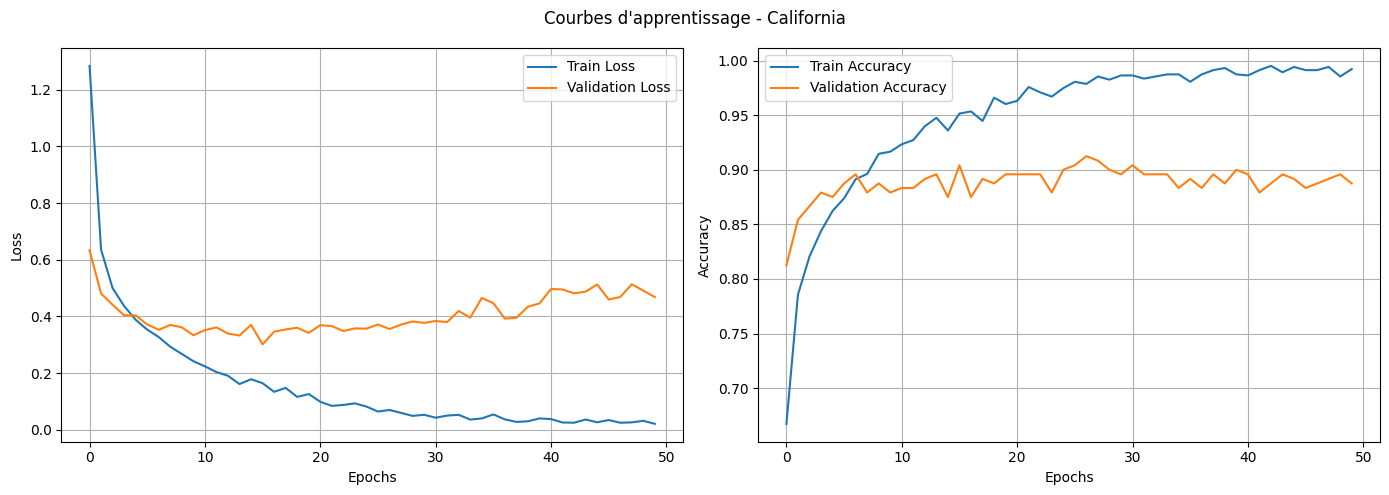


--- Entraînement du modèle pour ARKANSAS ---
Epoch 10/50 - Train Loss: 0.0653, Train Acc: 0.9792, Val Loss: 0.0878, Val Acc: 0.9667
Epoch 20/50 - Train Loss: 0.0213, Train Acc: 0.9927, Val Loss: 0.0724, Val Acc: 0.9750
Epoch 30/50 - Train Loss: 0.0102, Train Acc: 0.9979, Val Loss: 0.0646, Val Acc: 0.9750
Epoch 40/50 - Train Loss: 0.0067, Train Acc: 0.9979, Val Loss: 0.0525, Val Acc: 0.9792
Epoch 50/50 - Train Loss: 0.0193, Train Acc: 0.9948, Val Loss: 0.0820, Val Acc: 0.9750


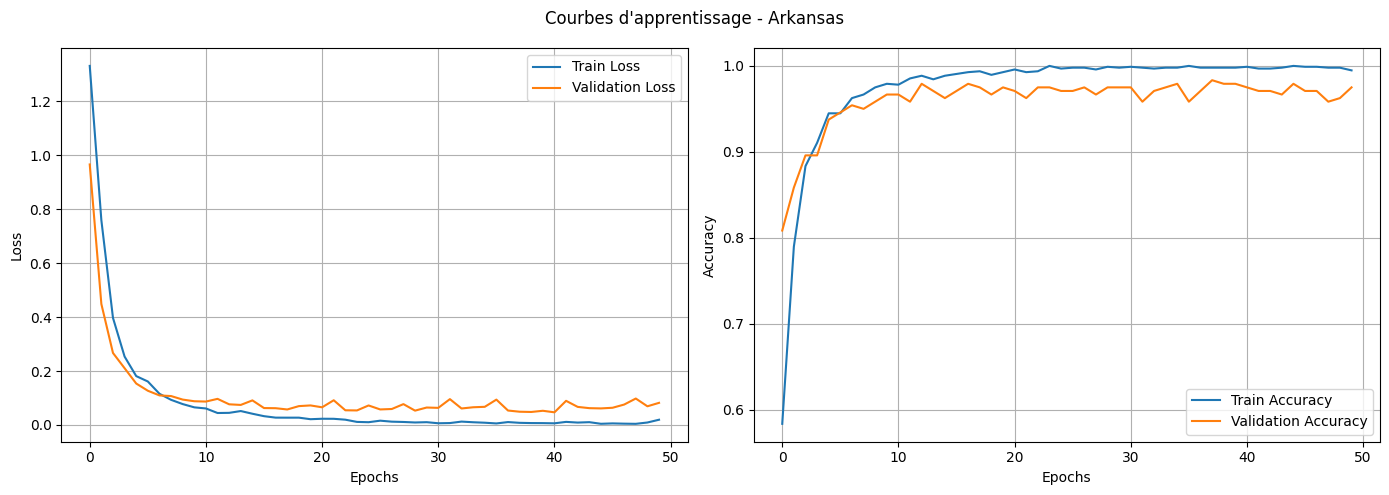

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import os
import json

PROCESSED_DIR = '/content/drive/MyDrive/Crop_Classification/data_part2/processed/splits'

def train_and_plot(state_name, n_cls, input_dim):
    print(f"\n--- Entraînement du modèle pour {state_name.upper()} ---")

    split_dir = os.path.join(PROCESSED_DIR, state_name)

    X_s2 = np.load(os.path.join(split_dir, 'X_s2.npy'))
    X_env = np.load(os.path.join(split_dir, 'X_env.npy'))
    y = np.load(os.path.join(split_dir, 'y.npy'))

    train_idx = np.load(os.path.join(split_dir, 'train_idx.npy'))
    val_idx = np.load(os.path.join(split_dir, 'val_idx.npy'))

    X_train = np.concatenate([X_s2[train_idx], X_env[train_idx]], axis=1)
    X_val = np.concatenate([X_s2[val_idx], X_env[val_idx]], axis=1)
    y_train = y[train_idx]
    y_val = y[val_idx]

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.long)

    batch_size = 64
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)

    class SimpleNN(nn.Module):
        def __init__(self, input_dim, hidden_dim, n_cls):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(hidden_dim // 2, n_cls)
            )

        def forward(self, x):
            return self.net(x)

    hidden_dim = 128
    model = SimpleNN(X_train.shape[1], hidden_dim, n_cls)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()

    epochs = 50
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_preds, train_labels = [], []

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)

        model.eval()
        val_loss = 0.0
        val_preds, val_labels = [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(y_batch.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Courbes d'apprentissage - {state_name.capitalize()}")

    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(train_accs, label='Train Accuracy')
    ax2.plot(val_accs, label='Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

with open(os.path.join(PROCESSED_DIR, 'california', 'metadata.json'), 'r') as f:
    meta_ca = json.load(f)
with open(os.path.join(PROCESSED_DIR, 'arkansas', 'metadata.json'), 'r') as f:
    meta_ar = json.load(f)

train_and_plot('california', meta_ca['n_classes'], meta_ca['s2_shape'][1] + meta_ca['env_shape'][1])
train_and_plot('arkansas', meta_ar['n_classes'], meta_ar['s2_shape'][1] + meta_ar['env_shape'][1])

## 📋 Cellule 14 — Tableau récapitulatif final (California + Arkansas)

In [ ]:
print('='*75)
print('  RÉSULTATS COMPLETS — ÉTUDE D\'ABLATION')
print('  California ET Arkansas — 5 Configurations')
print('='*75)

rows = []
for state in ['california', 'arkansas']:
    for cfg in CONFIGS:
        res = all_results[state][cfg['name']]
        rows.append({
            'État'         : state.capitalize(),
            'Configuration': cfg['name'].split(' — ')[1],
            'OA'           : f"{res['OA']:.4f}",
            'Kappa'        : f"{res['Kappa']:.4f}",
            'F1'           : f"{res['F1']:.4f}",
            'Params'       : f"{res['n_params']:,}"
        })

df_final = pd.DataFrame(rows)
print(df_final.to_string(index=False))
df_final.to_csv('/content/ablation_final_results.csv', index=False)

print('\n' + '='*75)
print('  ANALYSE : Impact des covariables par état')
print('='*75)
for state in ['california', 'arkansas']:
    res = all_results[state]
    base_oa = float(res[CONFIGS[0]['name']]['OA'])
    best_cfg= max(CONFIGS[1:], key=lambda c: float(res[c['name']]['OA']))
    best_oa = float(res[best_cfg['name']]['OA'])
    print(f'\n  {state.upper()} :')
    print(f'    Baseline          : OA={base_oa:.4f}')
    print(f'    Meilleure config  : {best_cfg["short"].replace(chr(10)," ")} → OA={best_oa:.4f}')
    print(f'    Gain total        : +{(best_oa-base_oa)*100:.2f} pts')

  RÉSULTATS COMPLETS — ÉTUDE D'ABLATION
  California ET Arkansas — 5 Configurations
      État        Configuration     OA  Kappa     F1 Params
California   S2 only (Baseline) 0.9230 0.8854 0.6974 39,756
California          S2 + Climat 0.9540 0.9310 0.7317 39,896
California             S2 + Sol 0.9433 0.9146 0.7164 39,896
California     S2 + Topographie 0.9123 0.8698 0.6849 39,886
California S2 + All Covariables 0.9671 0.9503 0.7474 39,946
  Arkansas   S2 only (Baseline) 0.9601 0.9360 0.9018 39,675
  Arkansas          S2 + Climat 0.9544 0.9272 0.8833 39,815
  Arkansas             S2 + Sol 0.9531 0.9253 0.8866 39,815
  Arkansas     S2 + Topographie 0.9449 0.9128 0.8721 39,805
  Arkansas S2 + All Covariables 0.9354 0.8981 0.8647 39,865

  ANALYSE : Impact des covariables par état

  CALIFORNIA :
    Baseline          : OA=0.9230
    Meilleure config  : S2+All Covariables → OA=0.9671
    Gain total        : +4.40 pts

  ARKANSAS :
    Baseline          : OA=0.9601
    Meilleure config  : 